In [ ]:
import os
import random
import shutil
import pickle
from astropy.io import fits

# Directorios de origen y destino
src_folder = "spectrums2"
dst_folder = "spectrums training 100k"

# Crear el directorio de destino si no existe
if not os.path.exists(dst_folder):
    os.makedirs(dst_folder)

# Definir los dos intervalos de redshift (ejemplo)
target_range1 = (0.2, 0.3)   # Primer intervalo: de 0.9 a 1.1
target_range2 = (0.2, 0.3)   # Segundo intervalo: de 1.1 a 2.0

# Número de archivos a copiar (total de ambos intervalos)
num_files_to_add = 1500

# Obtener la lista de todos los archivos .fits en el directorio de origen
all_files = [file for file in os.listdir(src_folder) if file.lower().endswith(".fits")]

# Randomizar la lista de archivos
random.shuffle(all_files)

# Diccionario para almacenar los redshifts de los archivos que se seleccionen
redshift_dict = {}

# Lista para almacenar los archivos seleccionados
selected_files = []
count = 0

# Recorrer la lista randomizada hasta alcanzar el número deseado
for file in all_files:
    src_path = os.path.join(src_folder, file)
    try:
        with fits.open(src_path) as hdul:
            redshift = hdul[2].data["Z"][0]
            # Verificar si el redshift se encuentra en alguno de los intervalos definidos
            if (target_range1[0] <= redshift < target_range1[1]) or (target_range2[0] <= redshift < target_range2[1]):
                dst_path = os.path.join(dst_folder, file)
                # Si el archivo ya existe en el destino, se omite (no se añade su redshift)
                if os.path.exists(dst_path):
                    if file in redshift_dict:
                        del redshift_dict[file]
                    continue  # Omitir el archivo ya existente
                # Agregar el archivo a la lista de selección y almacenar su redshift
                selected_files.append(file)
                redshift_dict[file] = redshift
                count += 1
                if count % 100 == 0:
                    print(f"{count} archivos seleccionados...")
                if count >= num_files_to_add:
                    break
    except Exception as e:
        print(f"Error procesando {file}: {e}")

# Verificar si se han encontrado suficientes archivos
if len(selected_files) < num_files_to_add:
    print(f"Se encontraron solo {len(selected_files)} archivos válidos en los intervalos especificados, se requieren {num_files_to_add}.")
    exit(1)
else:
    print(f"Se seleccionaron {len(selected_files)} archivos que cumplen con los intervalos requeridos.")

# Copiar los archivos seleccionados al directorio de destino
for file in selected_files:
    src_path = os.path.join(src_folder, file)
    dst_path = os.path.join(dst_folder, file)
    shutil.copy(src_path, dst_path)
    print(f"Copiado: {file}")

print("Proceso de copia completado.")

# Ruta del archivo pickle que almacena el array de redshifts
pickle_file = "extra/redshift_array.pkl"

# Extraer los nuevos redshifts en forma de array (solo los valores)
new_redshifts = np.array(list(redshift_dict.values()))

# Cargar el contenido existente del archivo pickle (si existe) o inicializar un array vacío
if os.path.exists(pickle_file):
    try:
        with open(pickle_file, "rb") as f:
            existing_redshifts = pickle.load(f)
        # Verificar que existing_redshifts sea un numpy array, sino convertirlo
        if not isinstance(existing_redshifts, np.ndarray):
            existing_redshifts = np.array(existing_redshifts)
    except Exception as e:
        print(f"Error cargando el archivo pickle existente: {e}")
        existing_redshifts = np.array([])
else:
    existing_redshifts = np.array([])

# Concatenar los nuevos redshifts al array existente
updated_redshifts = np.concatenate((existing_redshifts, new_redshifts))

# Guardar el array actualizado en el archivo pickle, reemplazándolo
with open(pickle_file, "wb") as f:
    pickle.dump(updated_redshifts, f)

print(f"Se han actualizado los redshifts en '{pickle_file}'.")

100 archivos seleccionados...


In [ ]:
import os
import time
import random
import pickle
import numpy as np
from astropy.io import fits

def try_remove(file_path, attempts=3, delay=5):
    for attempt in range(attempts):
        try:
            os.remove(file_path)
            return True
        except OSError as e:
            # Verificar si el error es WinError 32 (archivo en uso)
            if hasattr(e, 'winerror') and e.winerror == 32:
                print(f"Archivo {file_path} en uso, reintentando en {delay} segundos... (intento {attempt+1}/{attempts})")
                time.sleep(delay)
            else:
                print(f"Error removiendo {file_path}: {e}")
                break
    return False

# Directorio que contiene los archivos FITS
src_folder = "spectrums training 100k"

# Ruta del archivo pickle que contiene los redshifts
pickle_path = "extra/redshift_array.pkl"

down = 0.3
up = 0.6
max_files = 1000

# Cargar el archivo pickle y convertirlo a una lista para facilitar la actualización
with open(pickle_path, "rb") as f:
    redshift_array = pickle.load(f)
redshift_list = list(redshift_array)

# Obtener la lista de archivos FITS y mezclarlos aleatoriamente
files = [file for file in os.listdir(src_folder) if file.lower().endswith(".fits")]
random.shuffle(files)

# Contador para limitar el número de archivos procesados
processed_count = 0

for file in files:
    if processed_count >= max_files:
        break
    file_path = os.path.join(src_folder, file)
    try:
        with fits.open(file_path) as hdul:
            # Se asume que el redshift se encuentra en la extensión 2, campo "Z"
            redshift = hdul[2].data["Z"][0]
        if down <= redshift < up:
            if try_remove(file_path):
                print(f"Eliminado: {file}")
                # Actualizar el pickle removiendo la primera ocurrencia del redshift
                try:
                    redshift_list.remove(redshift)
                    print(f"Redshift {redshift} removido del archivo pickle.")
                    processed_count += 1
                except ValueError:
                    print(f"Redshift {redshift} no se encontró en el archivo pickle.")
                # Guardar la lista actualizada de redshifts en el archivo pickle
                with open(pickle_path, "wb") as f:
                    pickle.dump(np.array(redshift_list), f)
            else:
                print(f"No se pudo eliminar: {file}")
    except Exception as e:
        print(f"Error procesando {file}: {e}")

print("Proceso de eliminación completado.")

Eliminado: spec-4218-55479-0894.fits
Redshift 3.335440158843994 removido del archivo pickle.
Eliminado: spec-3755-55504-0116.fits
Redshift 2.7956671714782715 removido del archivo pickle.
Eliminado: spec-6001-56072-0648.fits
Redshift 2.8056578636169434 removido del archivo pickle.
Eliminado: spec-5333-56001-0139.fits
Redshift 2.631082534790039 removido del archivo pickle.
Eliminado: spec-4885-55735-0606.fits
Redshift 2.578436851501465 removido del archivo pickle.
Eliminado: spec-4848-55955-0080.fits
Redshift 3.397451162338257 removido del archivo pickle.
Eliminado: spec-3772-55277-0568.fits
Redshift 3.148676872253418 removido del archivo pickle.
Eliminado: spec-4705-55705-0774.fits
Redshift 2.877492666244507 removido del archivo pickle.
Eliminado: spec-5113-55924-0434.fits
Redshift 2.6595520973205566 removido del archivo pickle.
Eliminado: spec-3929-55335-0786.fits
Redshift 2.815464973449707 removido del archivo pickle.
Eliminado: spec-7101-56659-0922.fits
Redshift 3.573699474334717 rem

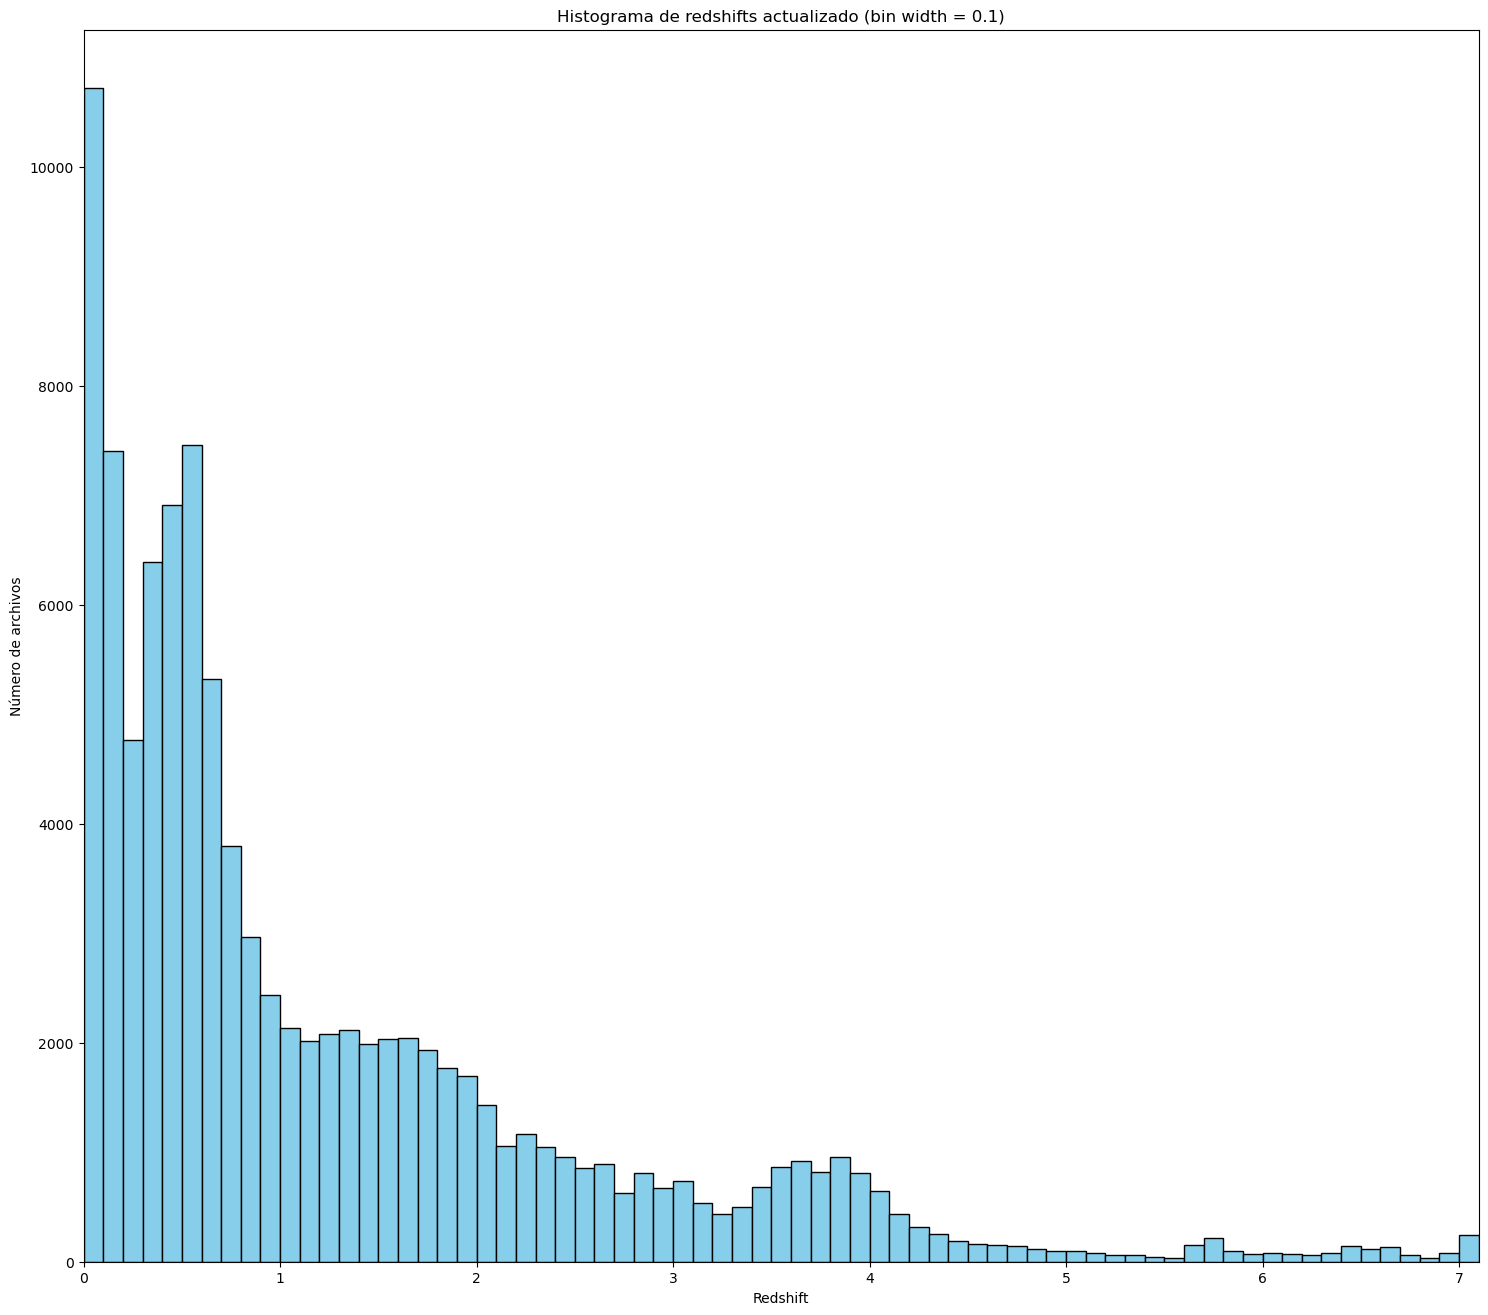

In [ ]:
import os
import pickle
import numpy as np
import matplotlib.pyplot as plt

# Cargar el array original de redshifts desde el pickle
with open("extra/redshift_array.pkl", "rb") as f:
    redshift_array = pickle.load(f)

# Definir los bins con intervalos de 0.1 y dibujar el histograma actualizado
bins = np.arange(0, redshift_array.max() + 0.1, 0.1)
plt.figure(figsize=(18,16))
plt.hist(redshift_array, bins=bins, color='skyblue', edgecolor='black')
plt.xlabel("Redshift")
plt.ylabel("Número de archivos")
plt.title("Histograma de redshifts actualizado (bin width = 0.1)")
plt.xlim(0, 7.1)
plt.show()

# Guardar el array de redshifts en un archivo pickle
with open("extra/redshift_array.pkl", "wb") as f:
    pickle.dump(redshift_array, f)